# Capstone Project: Loan Default Prediction
**Dataset:** Loan_Default.csv — 148,670 loan applications (Kaggle)
**Goal:** Predict whether a loan applicant is likely to default, to help lenders reduce credit risk and improve approval decisions.

In [1]:
import pandas as pd

df = pd.read_csv('Loan_Default.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df['Status'].value_counts())
print(df.isnull().sum())

(148670, 34)
['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Cred

In [2]:
print(df['Status'].value_counts(normalize=True) * 100)

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

print(df.dtypes)

Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64
Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
LTV                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
age                           0.134526
submission_of_application     0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
dtype: float64
ID                             int64
year                           int64
loan_limit                       str
Gender                           str
approv_in_adv                    str
loan_type                        str
loan_purpose                     str
Credit_Worthiness                str
open_credit                      str
business_or_commercial           str

In [3]:
df = df.drop(columns=['ID'])

numeric_impute_cols = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'dtir1', 'property_value', 'income', 'LTV', 'term']

for col in numeric_impute_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_impute_cols = ['loan_limit', 'approv_in_adv', 'age', 'submission_of_application', 'loan_purpose', 'Neg_ammortization']

for col in categorical_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum().sum())
print(df.shape)

0
(148670, 33)


In [4]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(col, ":", df[col].nunique())

C:\Users\GHIUQO\AppData\Local\Temp\ipykernel_11256\332650396.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


loan_limit : 2
Gender : 4
approv_in_adv : 2
loan_type : 3
loan_purpose : 4
Credit_Worthiness : 2
open_credit : 2
business_or_commercial : 2
Neg_ammortization : 2
interest_only : 2
lump_sum_payment : 2
construction_type : 2
occupancy_type : 3
Secured_by : 2
total_units : 4
credit_type : 4
co-applicant_credit_type : 2
age : 7
submission_of_application : 2
Region : 4
Security_Type : 2


In [5]:
categorical_cols = df.select_dtypes(include='str').columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.dtypes.value_counts())

(148670, 50)
bool       38
float64     8
int64       4
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

x = df_encoded.drop(columns=['Status'])
y = df_encoded['Status']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:", y_train.value_counts())

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("After SMOTE:", y_train_smote.value_counts())
print("x_train_smote shape:", x_train_smote.shape)

Before SMOTE: Status
0    89625
1    29311
Name: count, dtype: int64
After SMOTE: Status
0    89625
1    89625
Name: count, dtype: int64
x_train_smote shape: (179250, 49)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train_smote, y_train_smote)
log_reg_preds = log_reg.predict(x_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_reg_preds))
print(classification_report(y_test, log_reg_preds))
print(confusion_matrix(y_test, log_reg_preds))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_smote, y_train_smote)
rf_preds = rf.predict(x_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))

D:\Python Version12.10\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
Accuracy: 0.5772179995964216
              precision    recall  f1-score   support

           0       0.86      0.52      0.65     22406
           1       0.34      0.75      0.47      7328

    accuracy                           0.58     29734
   macro avg       0.60      0.63      0.56     29734
weighted avg       0.73      0.58      0.60     29734

[[11683 10723]
 [ 1848  5480]]

=== Random Forest ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

[[22406     0]
 [    0  7328]]


In [8]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=x_train.columns)
print(importances.sort_values(ascending=False).head(10))

Interest_rate_spread                 0.302531
Upfront_charges                      0.261476
rate_of_interest                     0.217195
credit_type_EQUI                     0.059232
property_value                       0.022352
LTV                                  0.019687
submission_of_application_to_inst    0.018840
dtir1                                0.018290
co-applicant_credit_type_EXP         0.013177
loan_type_type2                      0.007496
dtype: float64


In [9]:
leaky_cols = ['Interest_rate_spread', 'Upfront_charges', 'rate_of_interest']

x = df_encoded.drop(columns=['Status'] + leaky_cols)
y = df_encoded['Status']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("x_train_smote shape:", x_train_smote.shape)

x_train_smote shape: (179250, 46)


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_smote)
x_test_scaled = scaler.transform(x_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train_scaled, y_train_smote)
log_reg_preds = log_reg.predict(x_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_reg_preds))
print(classification_report(y_test, log_reg_preds))
print(confusion_matrix(y_test, log_reg_preds))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_smote, y_train_smote)
rf_preds = rf.predict(x_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))

importances = pd.Series(rf.feature_importances_, index=x_train.columns)
print("\nTop 10 features:\n", importances.sort_values(ascending=False).head(10))

=== Logistic Regression ===
Accuracy: 0.8565615120737203
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22406
           1       0.81      0.54      0.65      7328

    accuracy                           0.86     29734
   macro avg       0.84      0.75      0.78     29734
weighted avg       0.85      0.86      0.85     29734

[[21483   923]
 [ 3342  3986]]

=== Random Forest ===
Accuracy: 0.8875361538978946
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     22406
           1       0.91      0.61      0.73      7328

    accuracy                           0.89     29734
   macro avg       0.89      0.79      0.83     29734
weighted avg       0.89      0.89      0.88     29734

[[21940   466]
 [ 2878  4450]]

Top 10 features:
 credit_type_EQUI                     0.122148
LTV                                  0.099874
dtir1                                0.094423
property_value    

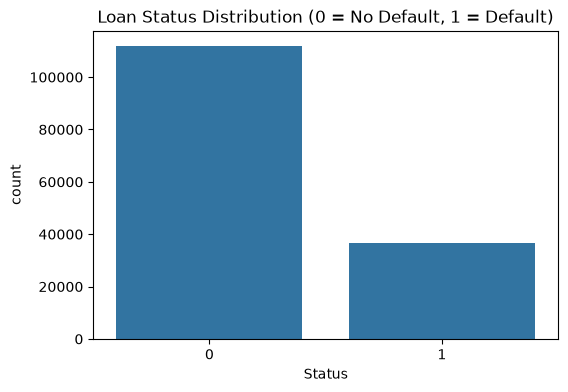

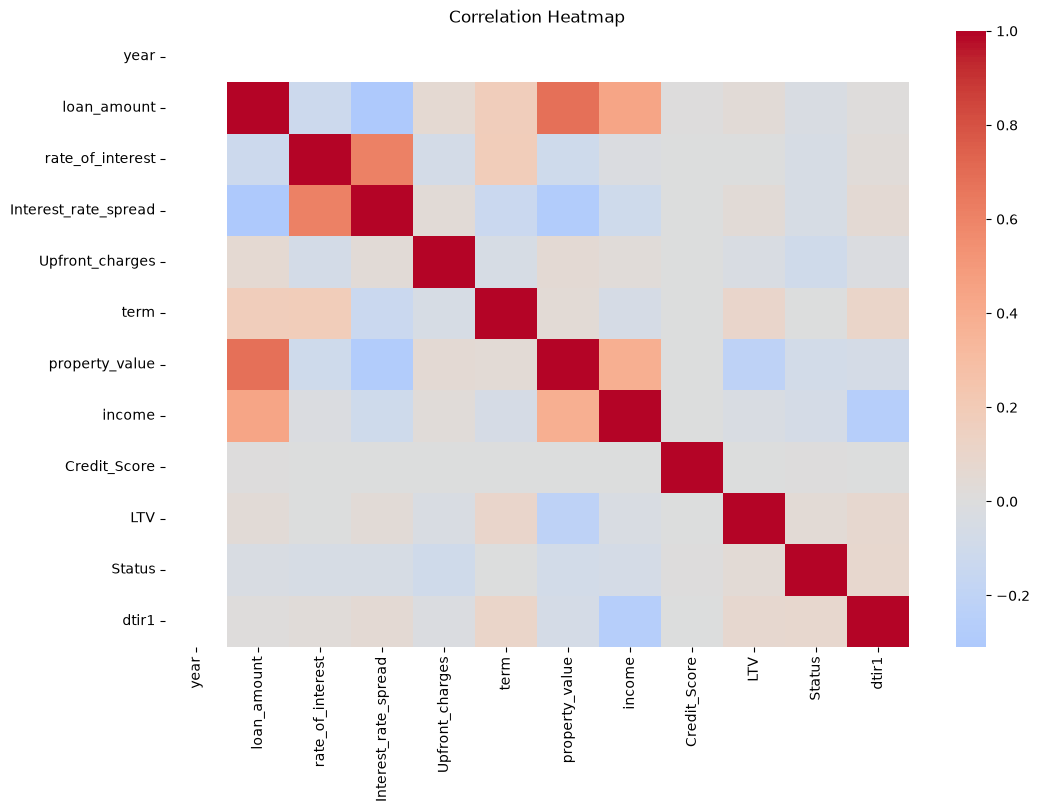

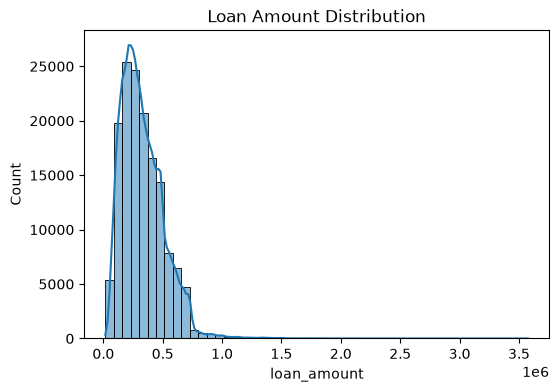

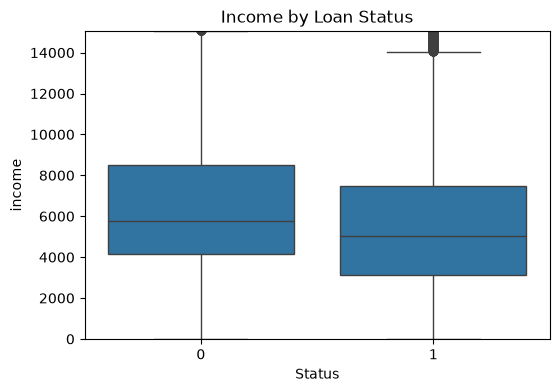

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df)
plt.title('Loan Status Distribution (0 = No Default, 1 = Default)')
plt.show()

plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['loan_amount'], bins=50, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Status', y='income', data=df)
plt.title('Income by Loan Status')
plt.ylim(0, df['income'].quantile(0.95))
plt.show()

In [12]:
import xgboost
print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.0


=== XGBoost ===
Accuracy: 0.8981300867693549
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     22406
           1       0.92      0.65      0.76      7328

    accuracy                           0.90     29734
   macro avg       0.91      0.81      0.85     29734
weighted avg       0.90      0.90      0.89     29734

[[21973   433]
 [ 2596  4732]]

=== ROC-AUC Scores ===
Logistic Regression: 0.8130918284228297
Random Forest: 0.8815749029813832
XGBoost: 0.8946589959089639


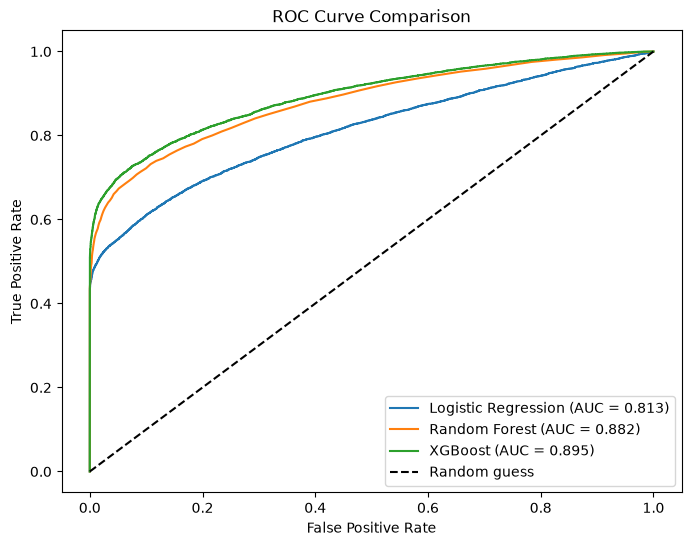

In [13]:
import re
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

x_train_xgb = x_train_smote.copy()
x_test_xgb = x_test.copy()
x_train_xgb.columns = [re.sub(r'[\[\]<>]', '', col) for col in x_train_xgb.columns]
x_test_xgb.columns = [re.sub(r'[\[\]<>]', '', col) for col in x_test_xgb.columns]

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(x_train_xgb, y_train_smote)
xgb_preds = xgb_model.predict(x_test_xgb)
xgb_probs = xgb_model.predict_proba(x_test_xgb)[:, 1]

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))
print(confusion_matrix(y_test, xgb_preds))

log_reg_probs = log_reg.predict_proba(x_test_scaled)[:, 1]
rf_probs = rf.predict_proba(x_test)[:, 1]

print("\n=== ROC-AUC Scores ===")
print("Logistic Regression:", roc_auc_score(y_test, log_reg_probs))
print("Random Forest:", roc_auc_score(y_test, rf_probs))
print("XGBoost:", roc_auc_score(y_test, xgb_probs))

plt.figure(figsize=(8,6))
for name, probs in [('Logistic Regression', log_reg_probs),
                     ('Random Forest', rf_probs),
                     ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [14]:
import joblib

categorical_options = {}
for col in categorical_cols:
    categorical_options[col] = sorted(df[col].dropna().unique().tolist())

joblib.dump(categorical_options, 'loan_default_categorical_options.pkl')
print("Categorical options saved")
for col, vals in categorical_options.items():
    print(col, ":", vals)

Categorical options saved
loan_limit : ['cf', 'ncf']
Gender : ['Female', 'Joint', 'Male', 'Sex Not Available']
approv_in_adv : ['nopre', 'pre']
loan_type : ['type1', 'type2', 'type3']
loan_purpose : ['p1', 'p2', 'p3', 'p4']
Credit_Worthiness : ['l1', 'l2']
open_credit : ['nopc', 'opc']
business_or_commercial : ['b/c', 'nob/c']
Neg_ammortization : ['neg_amm', 'not_neg']
interest_only : ['int_only', 'not_int']
lump_sum_payment : ['lpsm', 'not_lpsm']
construction_type : ['mh', 'sb']
occupancy_type : ['ir', 'pr', 'sr']
Secured_by : ['home', 'land']
total_units : ['1U', '2U', '3U', '4U']
credit_type : ['CIB', 'CRIF', 'EQUI', 'EXP']
co-applicant_credit_type : ['CIB', 'EXP']
age : ['25-34', '35-44', '45-54', '55-64', '65-74', '<25', '>74']
submission_of_application : ['not_inst', 'to_inst']
Region : ['North', 'North-East', 'central', 'south']
Security_Type : ['Indriect', 'direct']


In [15]:
joblib.dump(xgb_model, 'loan_default_model.pkl')
joblib.dump(scaler, 'loan_default_scaler.pkl')
joblib.dump(x_train_xgb.columns.tolist(), 'loan_default_columns.pkl')

print("Model, scaler, and columns saved successfully")

Model, scaler, and columns saved successfully


## Data Quality Report
- 148,670 rows, 34 original columns; dropped `ID` (no predictive value)
- Missing values ranged from <1% to 27% depending on column
- Numeric columns with moderate-to-high missing % (`rate_of_interest`, `Upfront_charges`, `dtir1`, `property_value`, `LTV`, `income`, `term`, `Interest_rate_spread`) imputed with median
- Categorical columns with low missing % (`loan_limit`, `approv_in_adv`, `loan_purpose`, `Neg_ammortization`, `age`, `submission_of_application`) imputed with mode
- Target (`Status`): 75.4% no-default vs 24.6% default — moderate class imbalance, handled with SMOTE on training data only

## Critical Finding: Data Leakage
Initial Random Forest model returned a suspicious 100% accuracy. Investigating feature importances revealed `rate_of_interest`, `Interest_rate_spread`, and `Upfront_charges` accounted for ~78% of the model's decision-making. These fields are only finalized once a loan is funded and performing — for defaulted loans, they were frequently left blank, meaning the model was learning "missing field → default" rather than genuine risk signals. All three columns were removed before final training to eliminate this leakage.

## Model Comparison (post-leakage-fix)
| Model | Accuracy | ROC-AUC | Default Recall |
|---|---|---|---|
| Logistic Regression | 85.7% | 0.813 | 0.54 |
| Random Forest | 88.8% | 0.882 | 0.61 |
| **XGBoost (selected)** | **89.8%** | **0.895** | **0.65** |

**Selected model: XGBoost** — best accuracy, best ROC-AUC, and best recall on the default class, which is the priority metric here since missing an actual default is the costlier business mistake.

## Business Insights
- Defaulters show visibly lower median income than non-defaulters, based on bivariate analysis.
- `rate_of_interest` and `Interest_rate_spread` are strongly correlated with each other (per the correlation heatmap) — a data collection insight for the business: these post-approval fields shouldn't be used for pre-approval risk scoring.
- Even the best model misses ~35% of actual defaults (recall 0.65) — a production system should treat this as a risk-scoring aid alongside human underwriting, not a fully automated approve/reject decision.
- Deployed via Streamlit, allowing loan officers to get an instant default-risk estimate from applicant details.